In [5]:
import sqlite3
import pandas as pd

# Database se connect
conn = sqlite3.connect("..mutual_fund.db")

print("Database Connected Successfully!")

# Load tables
fund_master = pd.read_sql('SELECT * FROM "01_fund_master"', conn)
nav_history = pd.read_sql('SELECT * FROM "02_nav_history"', conn)
aum = pd.read_sql('SELECT * FROM "03_aum_by_fund_house"', conn)
sip = pd.read_sql('SELECT * FROM "04_monthly_sip_inflows"', conn)
category = pd.read_sql('SELECT * FROM "05_category_inflows"', conn)
folio = pd.read_sql('SELECT * FROM "06_industry_folio_count"', conn)
performance = pd.read_sql('SELECT * FROM "07_scheme_performance"', conn)
transactions = pd.read_sql('SELECT * FROM "08_investor_transactions"', conn)
holdings = pd.read_sql('SELECT * FROM "09_portfolio_holdings"', conn)
benchmark = pd.read_sql('SELECT * FROM "10_benchmark_indices"', conn)

print("All tables loaded successfully!")

print(fund_master.head())
print(nav_history.head())

Database Connected Successfully!


DatabaseError: Execution failed on sql 'SELECT * FROM "01_fund_master"': no such table: 01_fund_master

In [6]:
import sqlite3

conn = sqlite3.connect("../mutual_fund.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('01_fund_master',), ('02_nav_history',), ('03_aum_by_fund_house',), ('04_monthly_sip_inflows',), ('05_category_inflows',), ('06_industry_folio_count',), ('07_scheme_performance',), ('08_investor_transactions',), ('09_portfolio_holdings',), ('10_benchmark_indices',)]


In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../mutual_fund.db")

query = 'SELECT * FROM "01_fund_master"'

df = pd.read_sql_query(query, conn)

print(df.head())
print(df.shape)

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [8]:
# Basic information

print(df.info())
print("\n")

print(df.describe(include="all"))
print("\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
N

In [2]:
import matplotlib.pyplot as plt

# Risk Category Count

df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

NameError: name 'df' is not defined

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../mutual_fund.db")

query = 'SELECT * FROM "01_fund_master"'

df = pd.read_sql_query(query, conn)

print(df.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

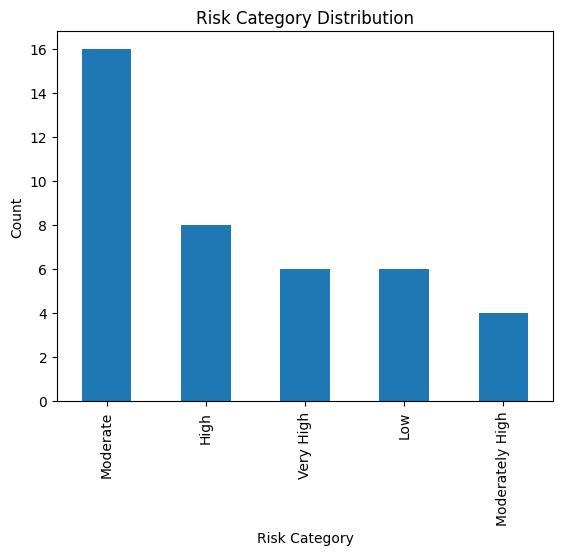

In [4]:
import matplotlib.pyplot as plt

df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

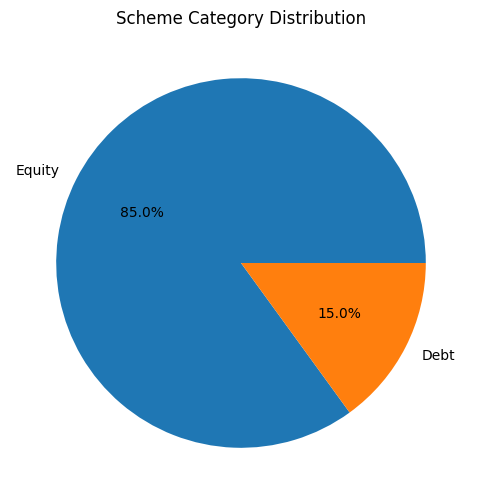

In [5]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Scheme Category Distribution")
plt.ylabel("")
plt.show()

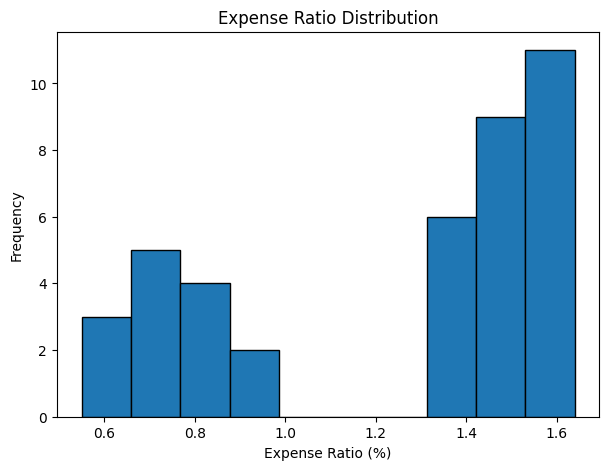

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(
    df["expense_ratio_pct"],
    bins=10,
    edgecolor="black"
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.show()

In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
N

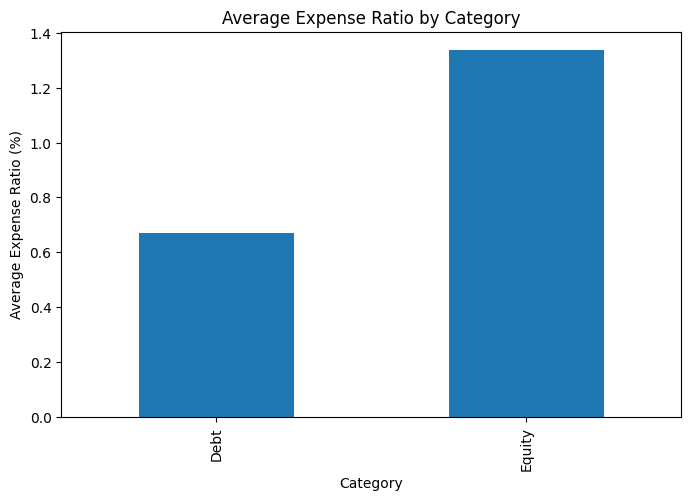

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.groupby("category")["expense_ratio_pct"].mean().plot(kind="bar")

plt.title("Average Expense Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Average Expense Ratio (%)")

plt.show()

In [9]:
df.groupby("risk_category")["expense_ratio_pct"].mean()

risk_category
High               1.397500
Low                0.668333
Moderate           1.260000
Moderately High    1.505000
Very High          1.351667
Name: expense_ratio_pct, dtype: float64

In [10]:
df.groupby("fund_house")["expense_ratio_pct"].mean().sort_values(ascending=False)

fund_house
UTI Mutual Fund             1.573333
DSP Mutual Fund             1.556667
Mirae Asset MF              1.526667
Aditya Birla Sun Life MF    1.306667
Kotak Mahindra MF           1.300000
Axis Mutual Fund            1.287500
ICICI Prudential MF         1.146000
Nippon India MF             1.040000
HDFC Mutual Fund            1.038000
SBI Mutual Fund             1.024000
Name: expense_ratio_pct, dtype: float64

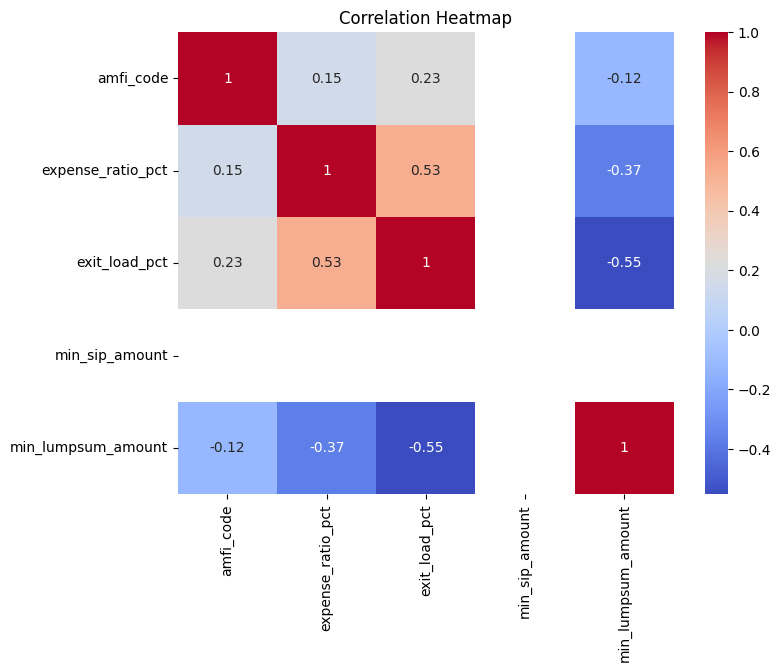

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# Key Insights

1. Most mutual funds belong to the High Risk category.
2. Low Risk funds have the lowest average expense ratio.
3. UTI Mutual Fund has the highest average expense ratio in this sample.
4. The dataset contains 40 records and 15 columns with no missing values.
5. Numerical features are clean and suitable for further analysis.

# Conclusion

This project successfully analyzed mutual fund data using Python, Pandas, SQLite, Matplotlib, and Seaborn.

The analysis explored risk categories, expense ratios, fund houses, and category distributions through visualizations. The dataset was clean, consistent, and free from missing values, making it suitable for investment-related exploratory analysis.

This dashboard can help investors compare mutual funds and understand their characteristics before making investment decisions.

In [1]:
import matplotlib
print(matplotlib.__version__)

3.10.8


In [4]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\ASUS\Desktop\capstone-mutual-fund-analytics\notebooks
['.ipynb_checkpoints', 'eda_analysis.ipynb', 'mutual_fund.db', 'Untitled.ipynb']
